# Project 3: Design and Implementation of a Sign Language Image Classifier
## Phase 1

In [7]:
import os
import random
import sys
import subprocess

def install_package(package_name):
    print(f"Installing package '{package_name}'... Please wait.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

try:
    import cv2
except ImportError:
    install_package('opencv-python')
    import cv2

try:
    import numpy as np
except ImportError:
    install_package('numpy')
    import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:
    install_package('matplotlib')
    import matplotlib.pyplot as plt

try:
    from sklearn.model_selection import train_test_split
except ImportError:
    install_package('scikit-learn')
    from sklearn.model_selection import train_test_split

plt.style.use('ggplot')
print("Importation is done!")

Importation is done!


### 1. Data Loading and Exploration (EDA)
In this section, we define the dataset path and check if the data is balanced. To do this, we plot the number of samples per class using a bar chart.

Total number of classes: 29

Minimum samples in a class: 3000
Maximum samples in a class: 3000
The dataset is perfectly balanced!



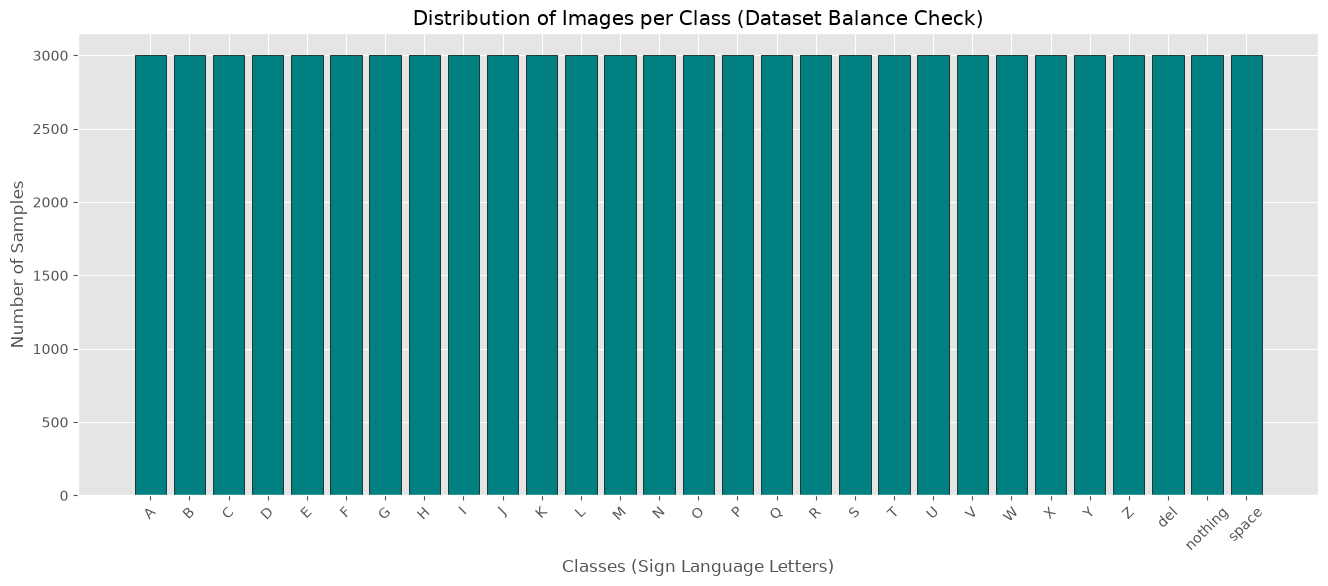

In [ ]:
# Dataset path
dataset_path = r'alphabet/asl_alphabet_train/asl_alphabet_train'
classes = sorted(os.listdir(dataset_path))
print(f"Total number of classes: {len(classes)}\n")

# Count images per class
class_counts = {}
for c in classes:
    class_path = os.path.join(dataset_path, c)
    if os.path.isdir(class_path):
        class_counts[c] = len(os.listdir(class_path))

# Check balance
min_samples = min(class_counts.values())
max_samples = max(class_counts.values())
print(f"Minimum samples in a class: {min_samples}")
print(f"Maximum samples in a class: {max_samples}")

if min_samples == max_samples:
    print("The dataset is perfectly balanced!\n")
else:
    print("The dataset is imbalanced.\n")

# Plot
plt.figure(figsize=(16, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='teal', edgecolor='black')
plt.title('Distribution of Images per Class (Dataset Balance Check)')
plt.xlabel('Classes (Sign Language Letters)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

### 2. Sample Visualization
To better understand the dataset, we randomly select one image from each class and display it along with its label in a grid.

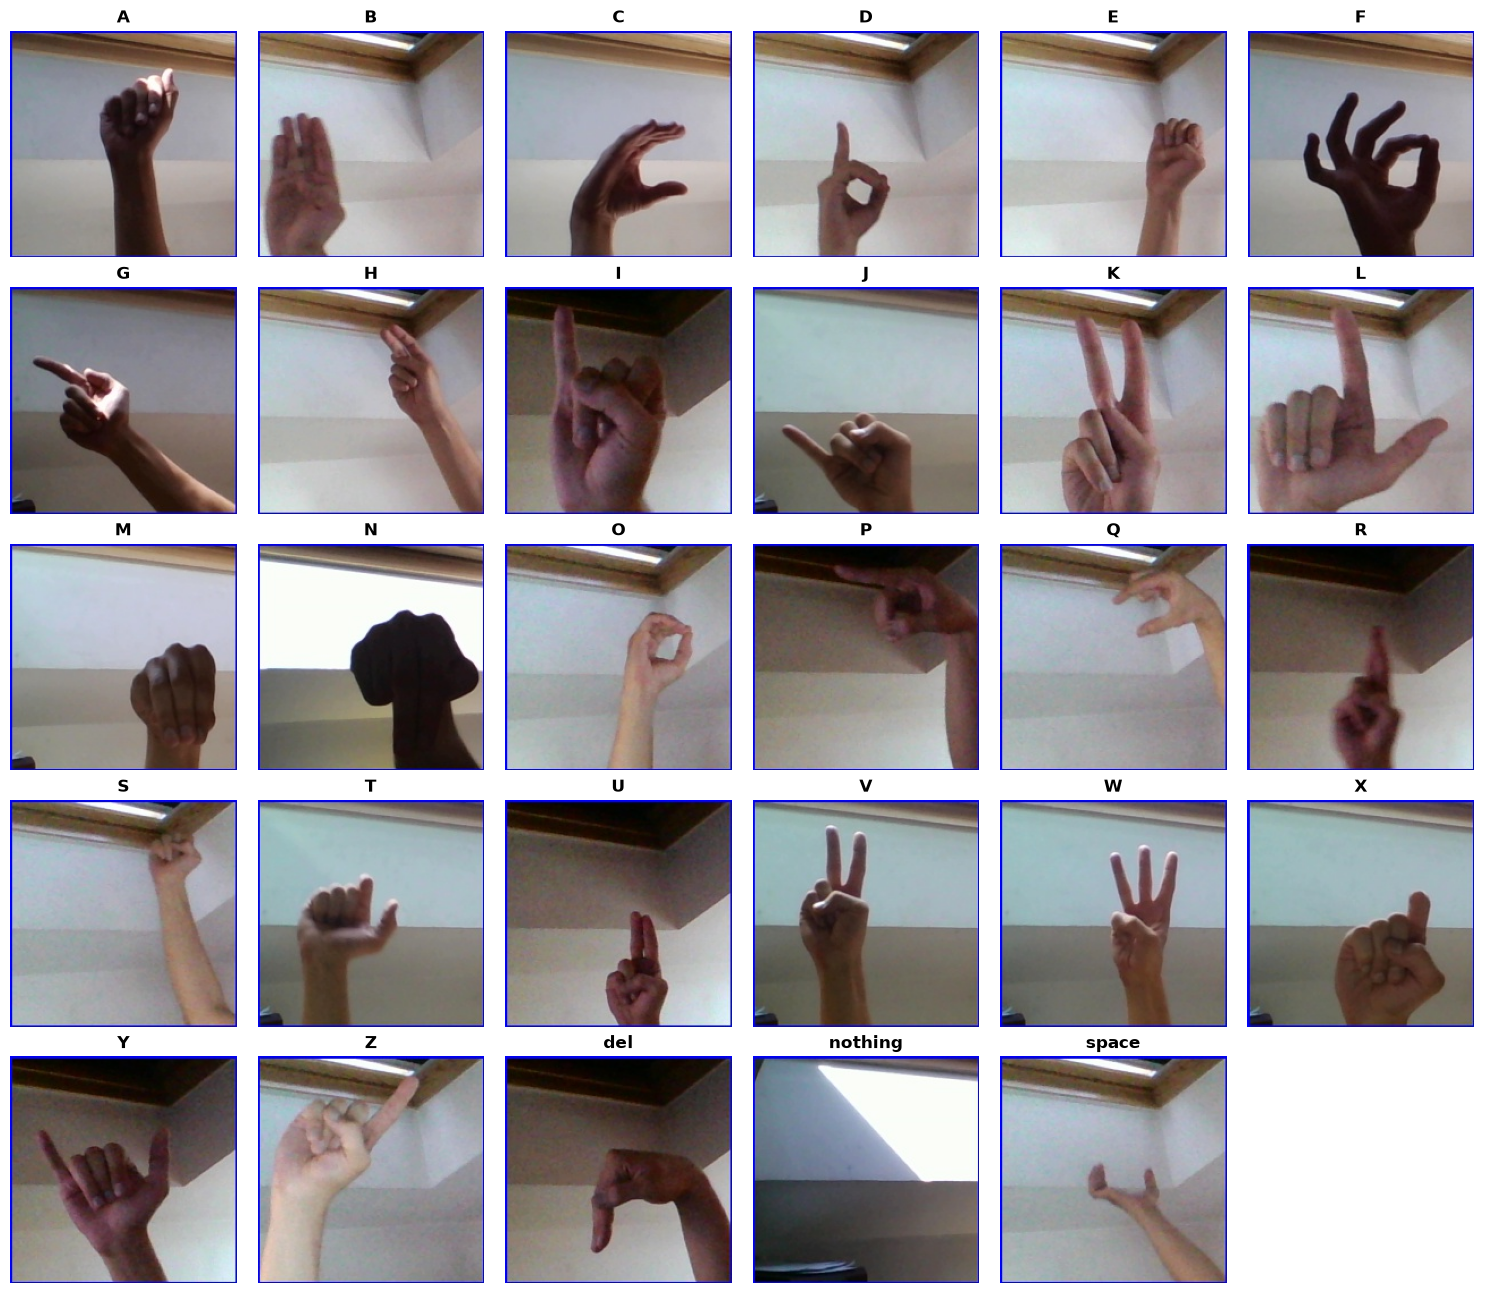

In [14]:
# Create a 5x6 grid (for 29 classes)
fig, axes = plt.subplots(5, 6, figsize=(15, 13))
axes = axes.flatten()

for i, c in enumerate(classes):
    class_path = os.path.join(dataset_path, c)
    images = os.listdir(class_path)
    
    # Random sample
    random_image_name = random.choice(images)
    img_path = os.path.join(class_path, random_image_name)
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display
    axes[i].imshow(img)
    axes[i].set_title(c, fontsize=12, fontweight='bold')
    axes[i].axis('off')

# Turn off remaining empty axes
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 3. Data Splitting and Preprocessing Function
Images must be standardized before feeding them into the neural network. We will write a function to resize them (e.g., to 64x64) and normalize pixel values to the [0, 1] range. Then, we will split the entire dataset using the standard 80% Train, 10% Validation, and 10% Test ratio.

In [ ]:
filepaths = []
labels = []

# Collect all paths and labels
for c in classes:
    class_path = os.path.join(dataset_path, c)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            filepaths.append(os.path.join(class_path, img_name))
            labels.append(c)

# Split data
# 'stratify' ensures class ratios are maintained across splits

# 80% Train,
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    filepaths, labels, test_size=0.20, random_state=42, stratify=labels
)

# 10% Validation, 10% Test
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training data count: {len(X_train_paths)}")
print(f"Validation data count: {len(X_val_paths)}")
print(f"Test data count: {len(X_test_paths)}\n")

def preprocess_image(image_path, size=(64, 64)):
    
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize
    img_resized = cv2.resize(img, size)
    
    # Normalize pixel values
    img_normalized = img_resized.astype(np.float32) / 255.0
    
    return img_normalized

# Test on a single sample
sample_img = preprocess_image(X_train_paths[0], size=(64, 64))
print(f"Output image shape after preprocessing: {sample_img.shape}")
print(f"Min pixel value: {sample_img.min():.1f} | Max pixel value: {sample_img.max():.1f}")

Training data count: 69600
Validation data count: 8700
Test data count: 8700

Output image shape after preprocessing: (64, 64, 3)
Min pixel value: 0.0 | Max pixel value: 1.0
